# Liver fibrosis in NHANES — stratified by sex and 10-year age band

**Reported categories** (LSM-based fibrosis stage, no steatosis gate; mutually exclusive, sum to
100% within each stratum): **<F1** (F0, LSM <6 kPa) · **F1** (6–<8) · **F2–3** (8–<15) ·
**>F3** (F4, ≥15 kPa).

**Is there enough data?** 12 strata (2 sexes × 6 bands), N ≈ 540–765 each. The <F1/F1/F2–3 groups
are well populated; **>F3 (F4) is sparse per cell (3–36 events)** — its trend is shown with a caution
flag and wide CIs. Correlations (section 3) use the full-MEC-sample risks only.

**Cohort.** NHANES 2017–March 2020 pre-pandemic, adults 18+ with a complete FibroScan exam,
MEC-weighted. (A CAP≥288 steatosis gate is *not* applied to these stage categories; the metabolic-
coupling section does use the MASLD-gated F-stage, matching the main analysis.)

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())
%matplotlib inline
import pandas as pd
import fibrosis_lib as fl, fibrosis_strat as fs, fibrosis_plots as fp
pd.set_option("display.max_columns", 40)

coh = fl.build_cohort()
counts = fs.stage_cell_counts(coh)
counts.to_csv("outputs/stratified_stage_cell_counts.csv", index=False)
counts   # unweighted event counts per stratum for the reported categories

,sex,age,N,<F1,F1,F2–3,>F3
0,Female,18-29,717,606,91,16,4
1,Female,30-39,611,511,65,27,8
2,Female,40-49,604,478,83,40,3
3,Female,50-59,689,483,132,57,17
4,Female,60-69,721,505,131,70,15
5,Female,70-80,564,405,99,49,11
6,Male,18-29,764,550,163,43,8
7,Male,30-39,540,385,114,36,5
8,Male,40-49,590,386,147,47,10
9,Male,50-59,599,371,141,69,18


## 1. Fibrosis-stage distribution (<F1 / F1 / F2–3 / >F3)

Weighted prevalence with 95% CIs, per sex × age band. Reading down the bands: the distribution shifts
out of <F1 into the higher groups with age, and men carry more F2–3 and >F3 at every age.

In [2]:
dist = fs.stage_distribution(coh)
dist.to_csv("outputs/stratified_stage_distribution.csv", index=False)
# wide view: prevalence (%) by category
dist.pivot(index=["sex", "age"], columns="category", values="pct")[["<F1", "F1", "F2–3", ">F3"]]

category       <F1    F1  F2–3  >F3
sex    age                         
Female 18-29  84.2  12.8   2.7  0.3
       30-39  81.7  11.8   5.0  1.5
       40-49  80.1  14.6   4.9  0.4
       50-59  72.4  19.7   6.6  1.3
       60-69  71.6  18.6   8.3  1.5
       70-80  71.4  17.9   8.8  1.9
Male   18-29  70.8  20.4   7.4  1.5
       30-39  74.5  18.0   6.4  1.1
       40-49  66.8  22.2   8.8  2.1
       50-59  67.2  17.5  12.4  2.9
       60-69  61.8  23.7  10.3  4.2
       70-80  61.7  24.6   9.7  4.1

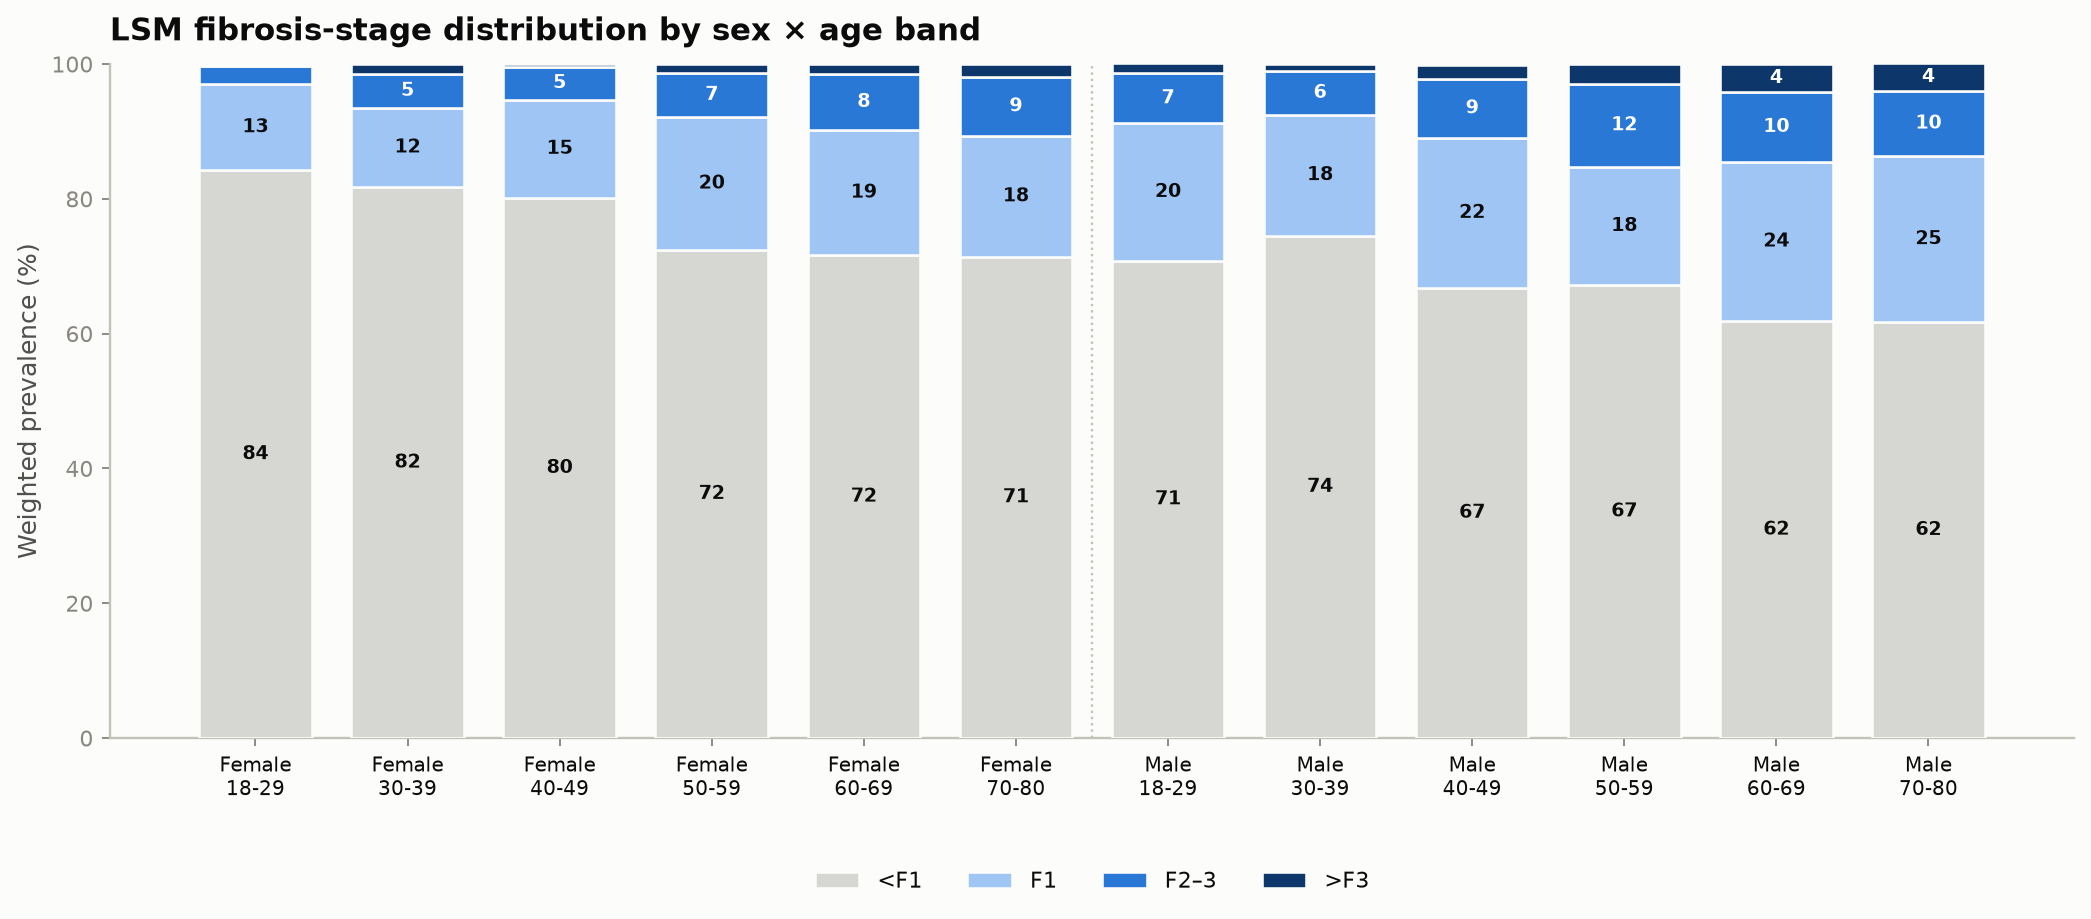

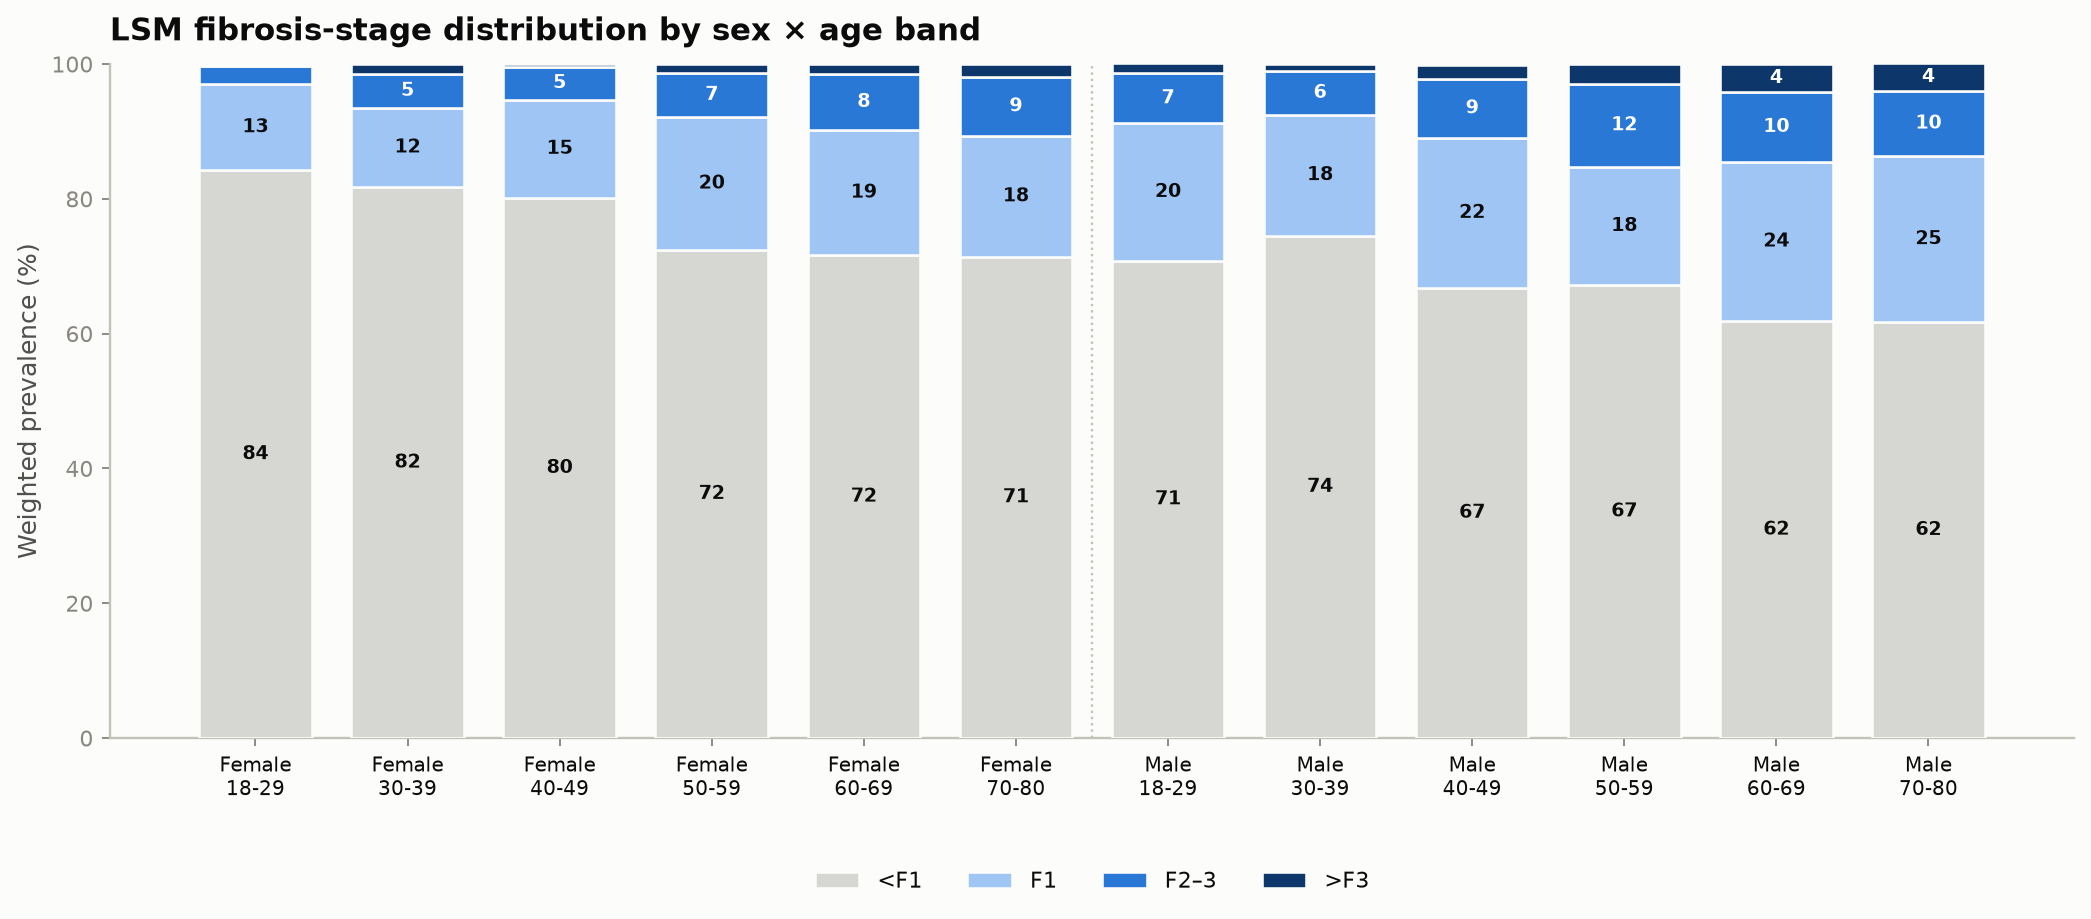

In [3]:
fp.stage_distribution_fig(dist)

The two clinically important groups on their own, with 95% CIs. F2–3 rises with age and peaks in men
at 50–59 (~12%); >F3 is sparse — read the trend, not the points.

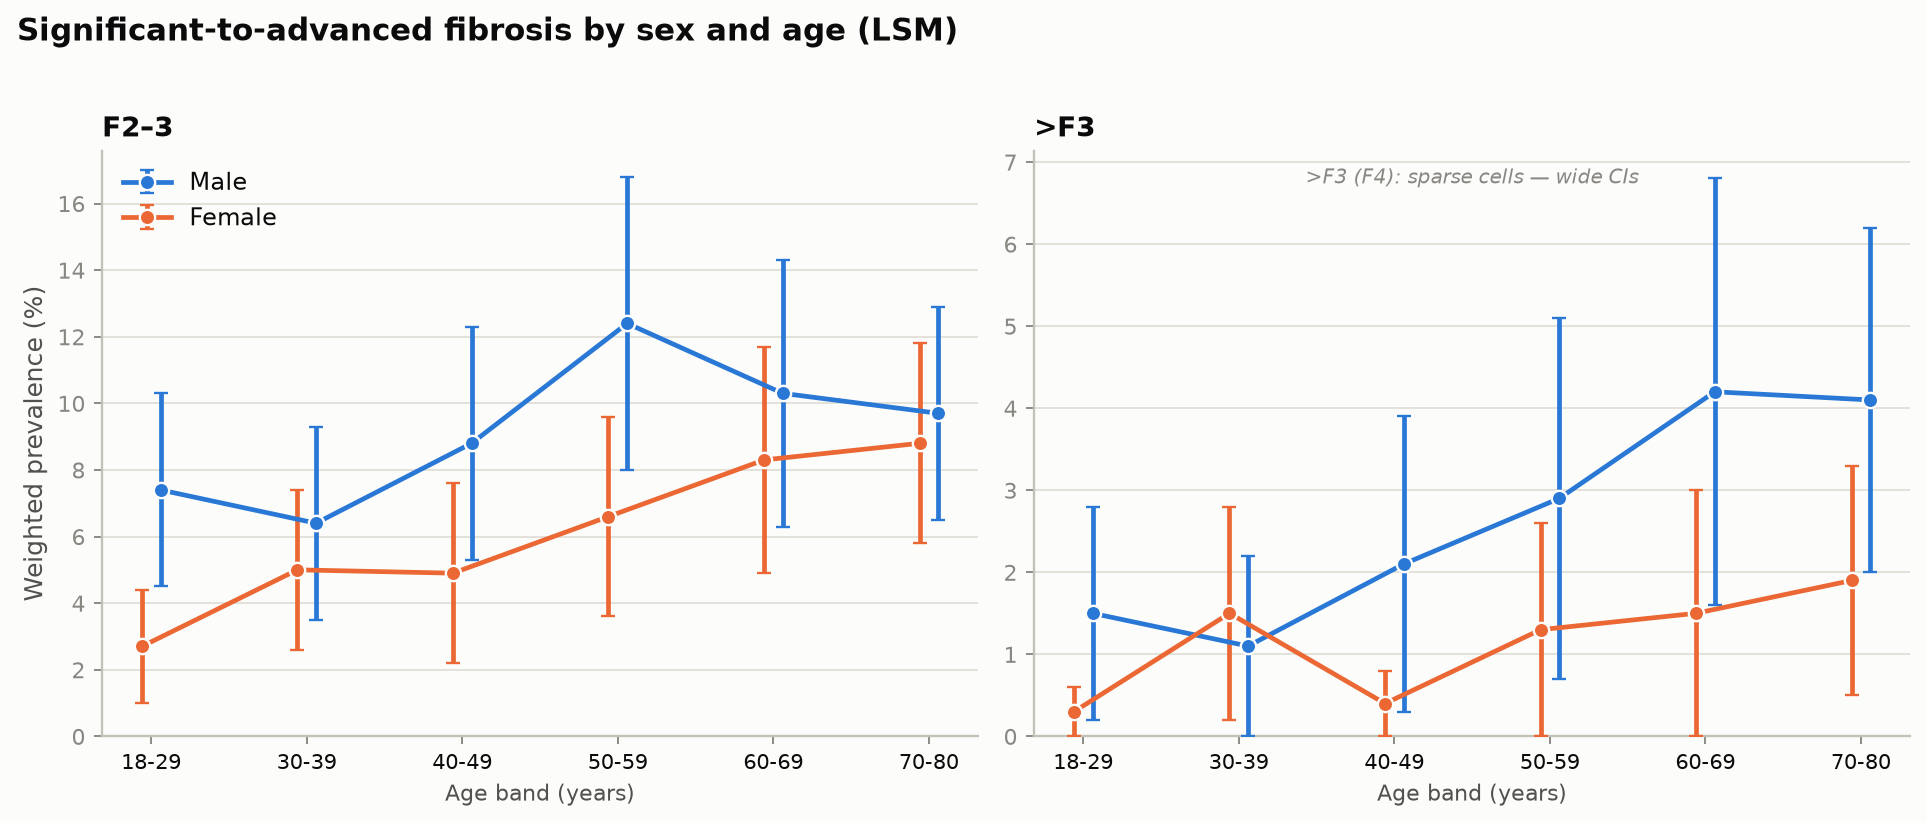

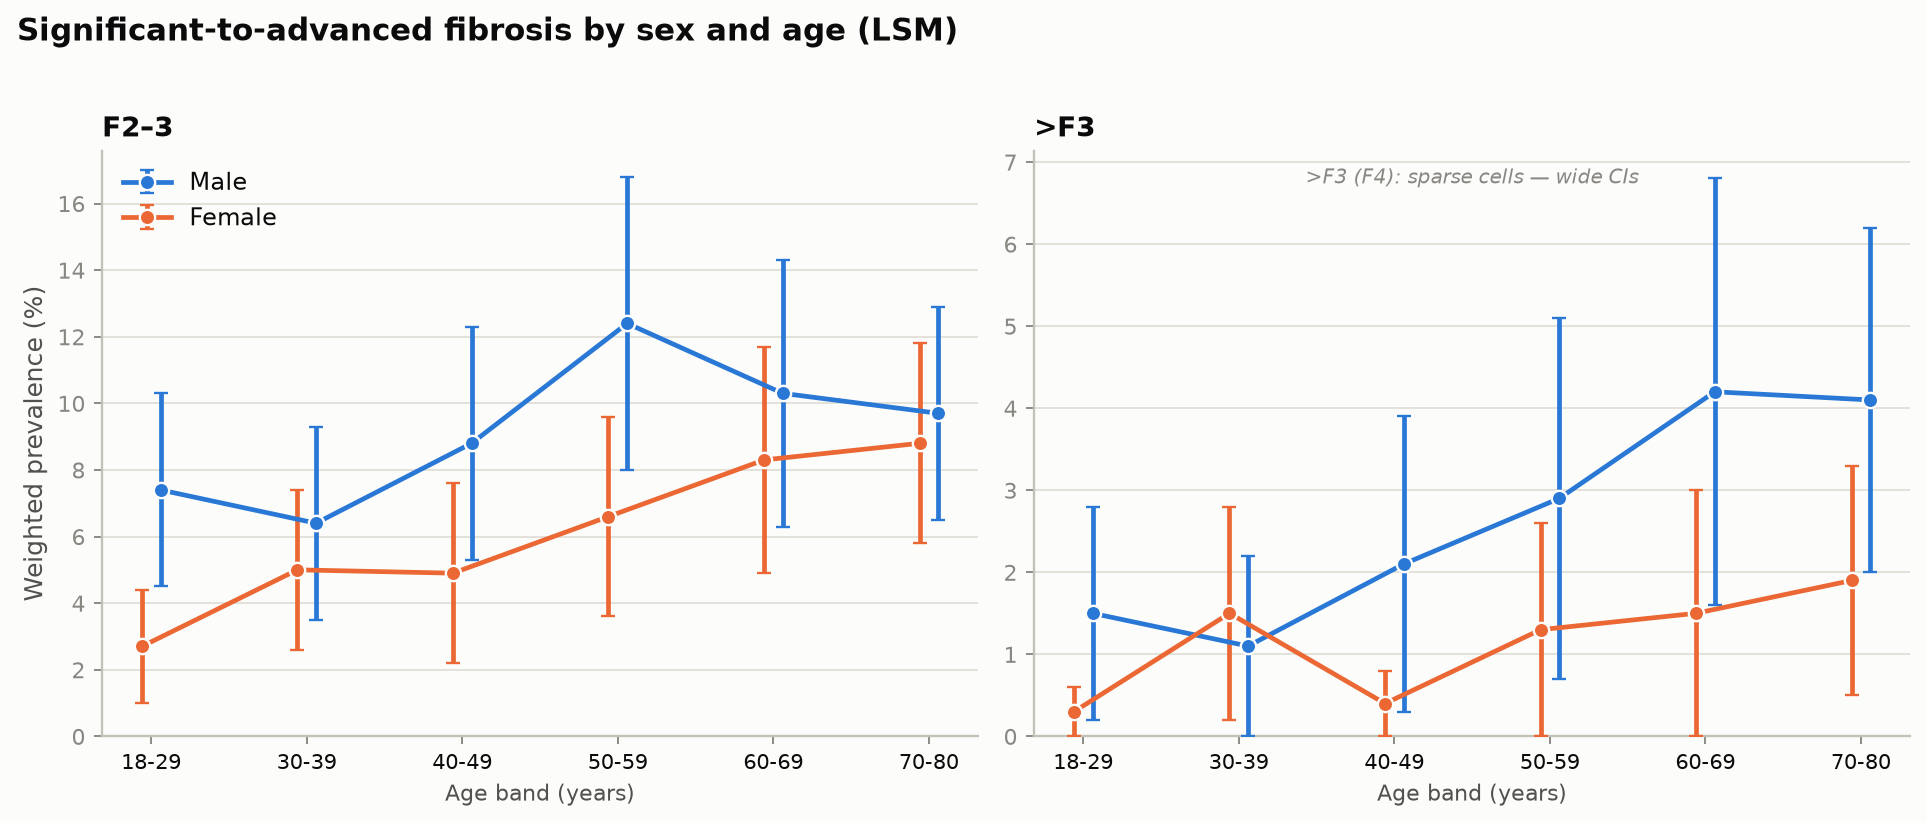

In [4]:
fp.stage_trend_fig(dist)

## 2. Metabolic coupling by sex × age band

Weighted Spearman ρ of the MASLD F-stage (gated at CAP≥288) with each full-sample metabolic risk,
within each stratum. Adiposity (waist/BMI) dominates in every cell (ρ≈0.35–0.48) and the coupling
attenuates in the oldest bands. Systolic BP and AST stay weak throughout.

In [5]:
corr = fs.stratified_correlation(coh)
corr.to_csv("outputs/stratified_correlations.csv")
corr

,Waist,BMI,HbA1c,HDL-C,ALT,AST,GGT,Systolic BP
Female 18-29,0.311,0.328,0.146,-0.193,0.276,0.176,0.240,-0.010
Female 30-39,0.391,0.392,0.310,-0.221,0.298,0.206,0.300,0.140
Female 40-49,0.413,0.422,0.239,-0.228,0.215,0.066,0.289,0.098
Female 50-59,0.455,0.468,0.258,-0.239,0.247,0.061,0.218,0.015
Female 60-69,0.444,0.415,0.260,-0.304,0.159,0.065,0.201,0.027
Female 70-80,0.227,0.202,0.237,-0.221,0.096,0.019,0.146,-0.041
Male 18-29,0.386,0.383,0.051,-0.238,0.323,0.161,0.260,0.077
Male 30-39,0.476,0.442,0.157,-0.264,0.361,0.266,0.226,0.240
Male 40-49,0.432,0.425,0.315,-0.202,0.289,0.137,0.242,0.150
Male 50-59,0.403,0.425,0.276,-0.216,0.246,0.203,0.276,0.048


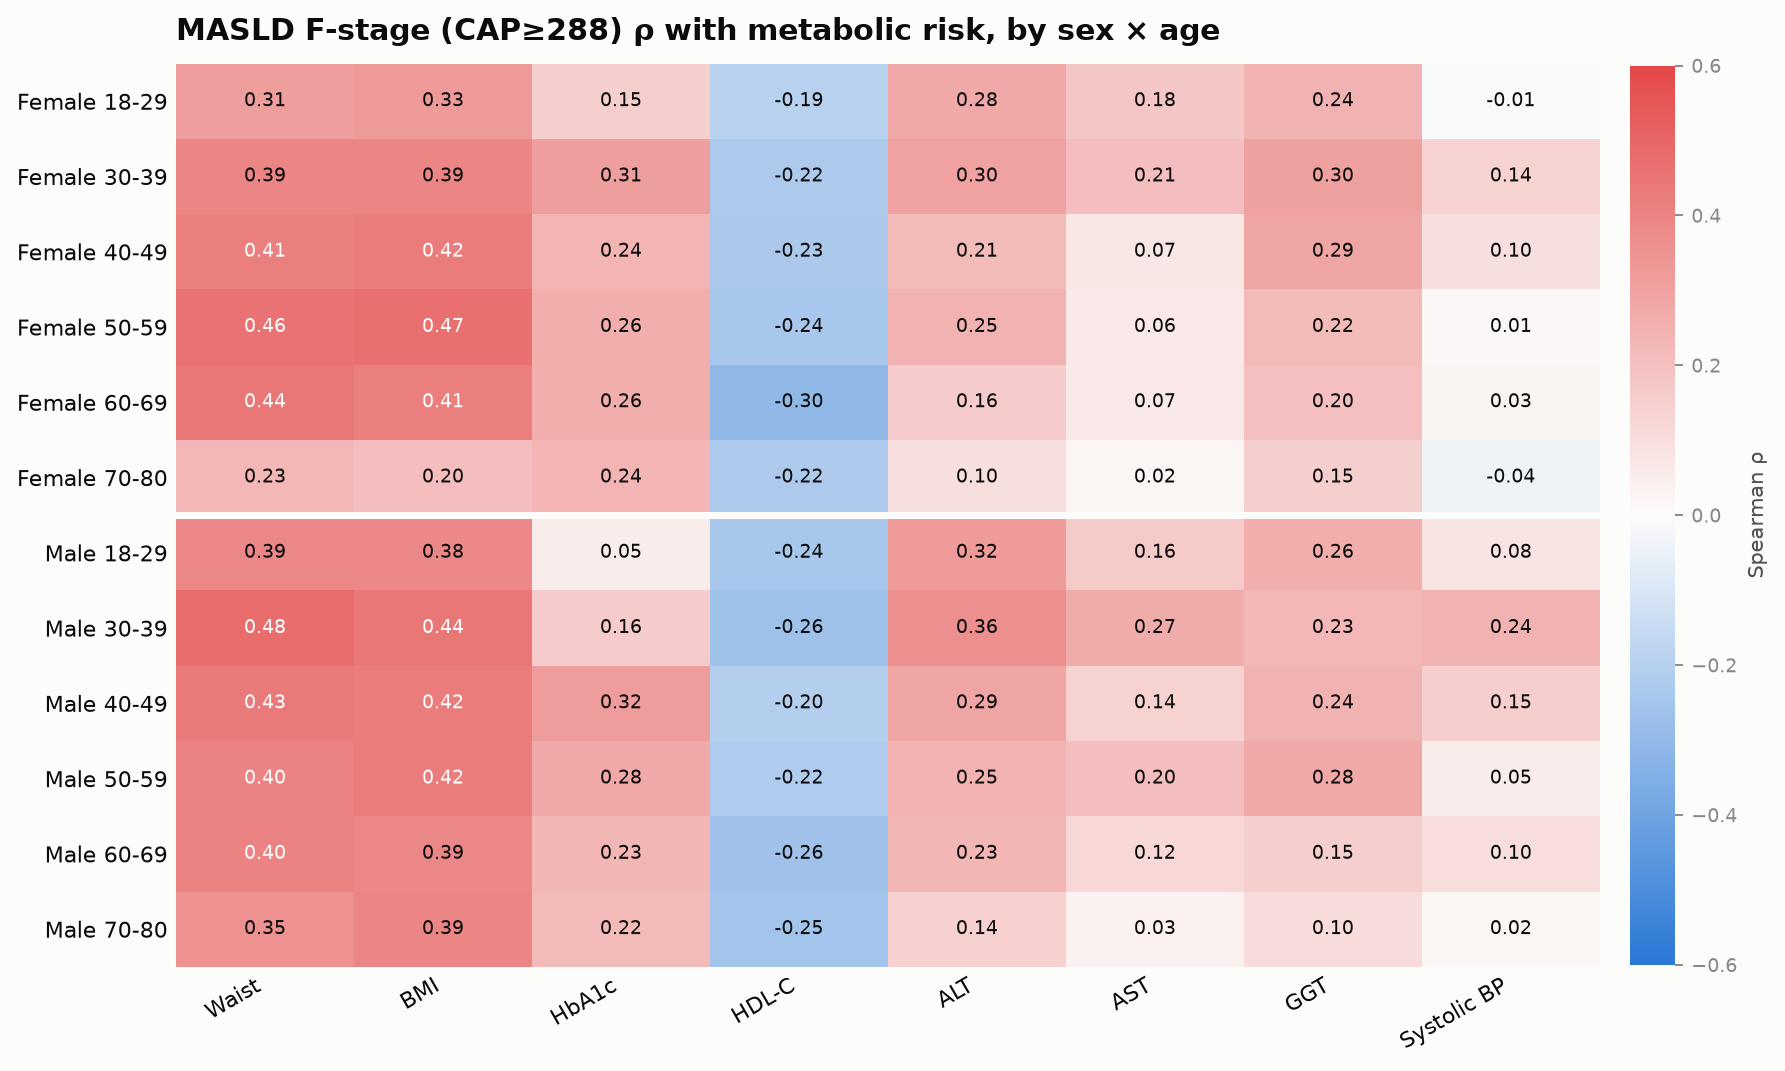

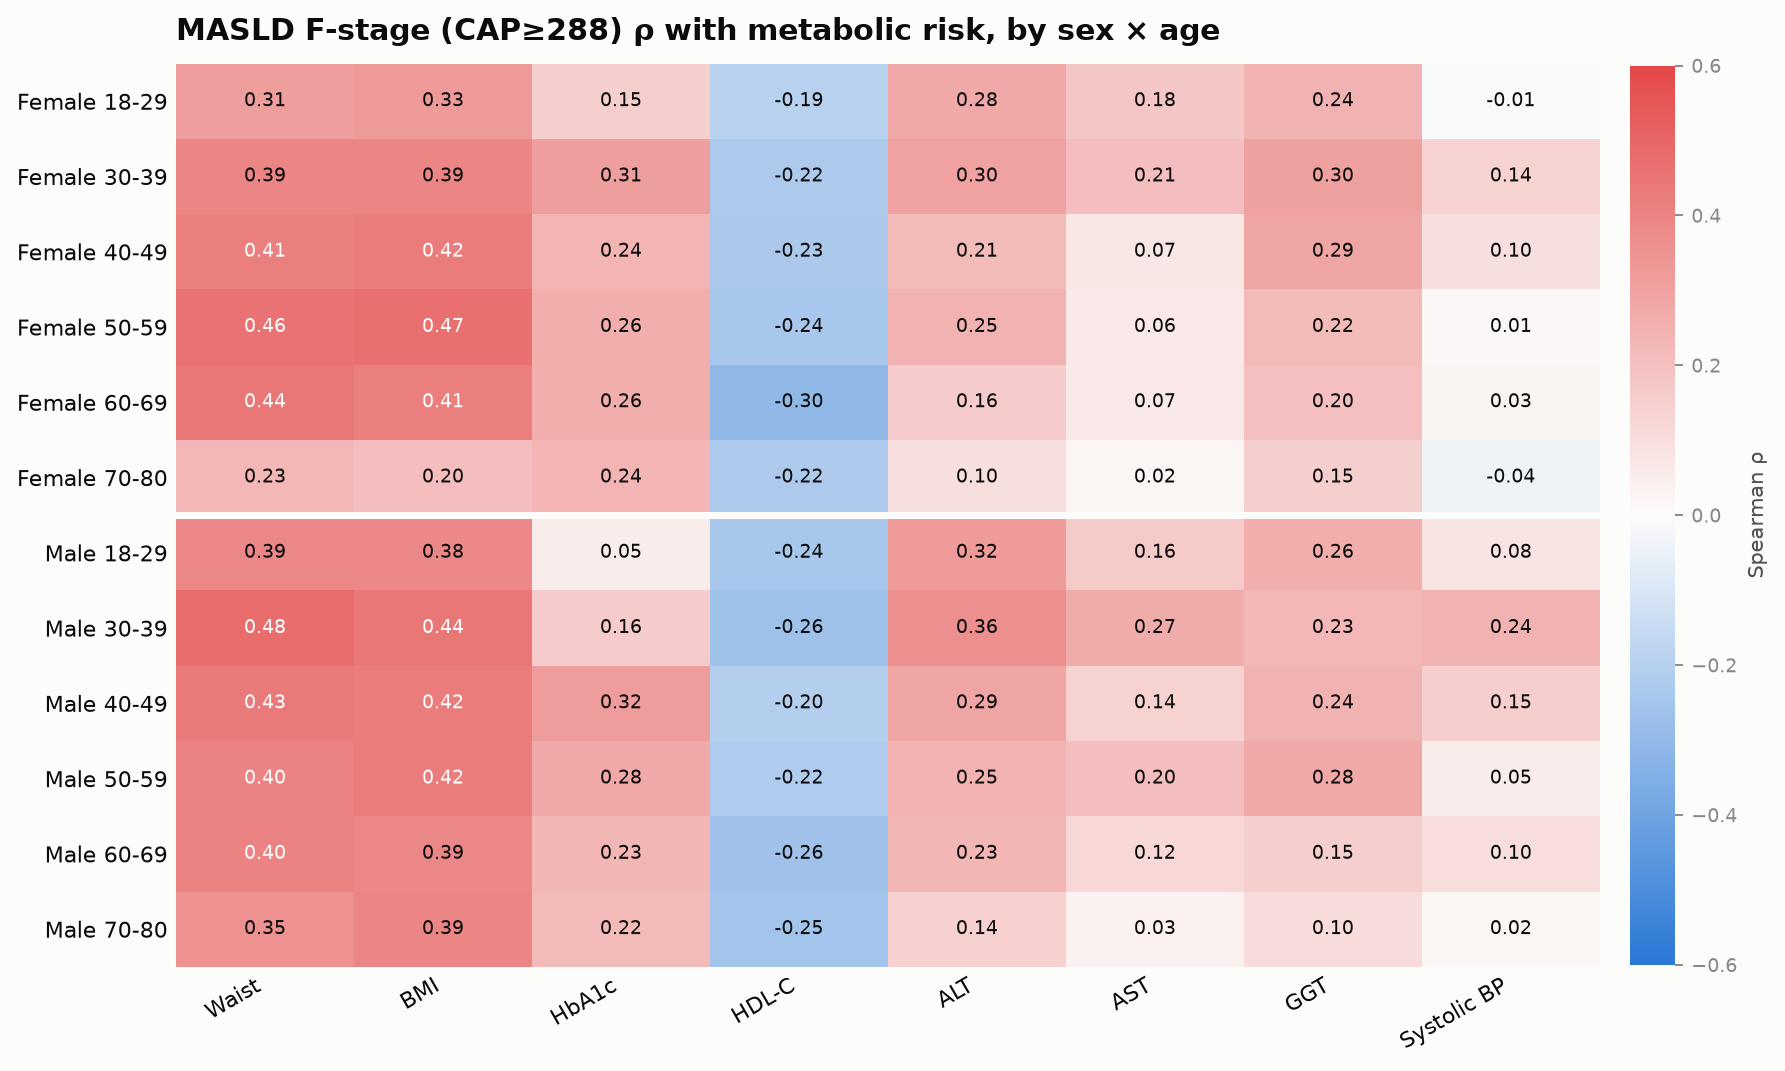

In [6]:
fp.stratified_corr_heatmap(corr)

## Caveats

- Prevalences MEC-weighted; CIs analytic (Fisher-z / normal on the weight-based effective N) and ignore
  PSU/stratum clustering — full survey SEs would be modestly wider, most in the smaller cells.
- **>F3 (F4)** is under-powered per cell (3–36 events); interpret advanced-disease strata cautiously and
  prefer a pooled model with age as a continuous covariate for that group.
- Correlations exclude the fasting-subsample labs (glucose/triglycerides/insulin) for sparsity.
- To gate these stage categories on steatosis (adding a "No MASLD" slice), filter `coh` to
  `coh.LUXCAPM >= cut` before calling `fs.stage_distribution`.